# Projections
This tutorial showcases how to deposit 3D particle fields onto 2D projection planes. These features are especially useful for creating images and other types of visualizations of 3D point clouds.

+ We will introduce the math behind the projection engine in `smudgy`, and how it relates to relevant methods and parameters.
+ We showcase a projection workflow comparing `isotropic` and `covariant` structures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import smudgy as sm

np.random.seed(10)

[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.13.14


[I 08/04/26 17:53:22.314 759198] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [2]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'

We will use the 3D swiss role dataset with the following parameters:

In [3]:
# Swiss roll parameters
height = 1.0
length = 5 * np.pi
noise  = 0.5

N = 500_000
weights = np.ones(N)

# Generate 3D Swiss roll dataset
t = length * (np.random.rand(N)) + 1.5 * np.pi  # t in [1.5pi, 3pi]
x = t * np.cos(t)
y = height * np.random.rand(N)
z = t * np.sin(t)

# Add noise
x += noise * np.random.randn(N)
y += noise * np.random.randn(N)
z += noise * np.random.randn(N)

# Rescale to [0, 1]
X_swiss = np.vstack((x, y, z)).T
min_X = X_swiss.min(axis=0)
max_X = X_swiss.max(axis=0)
positions = (X_swiss - min_X) / (max_X - min_X + 1e-8)* 0.99

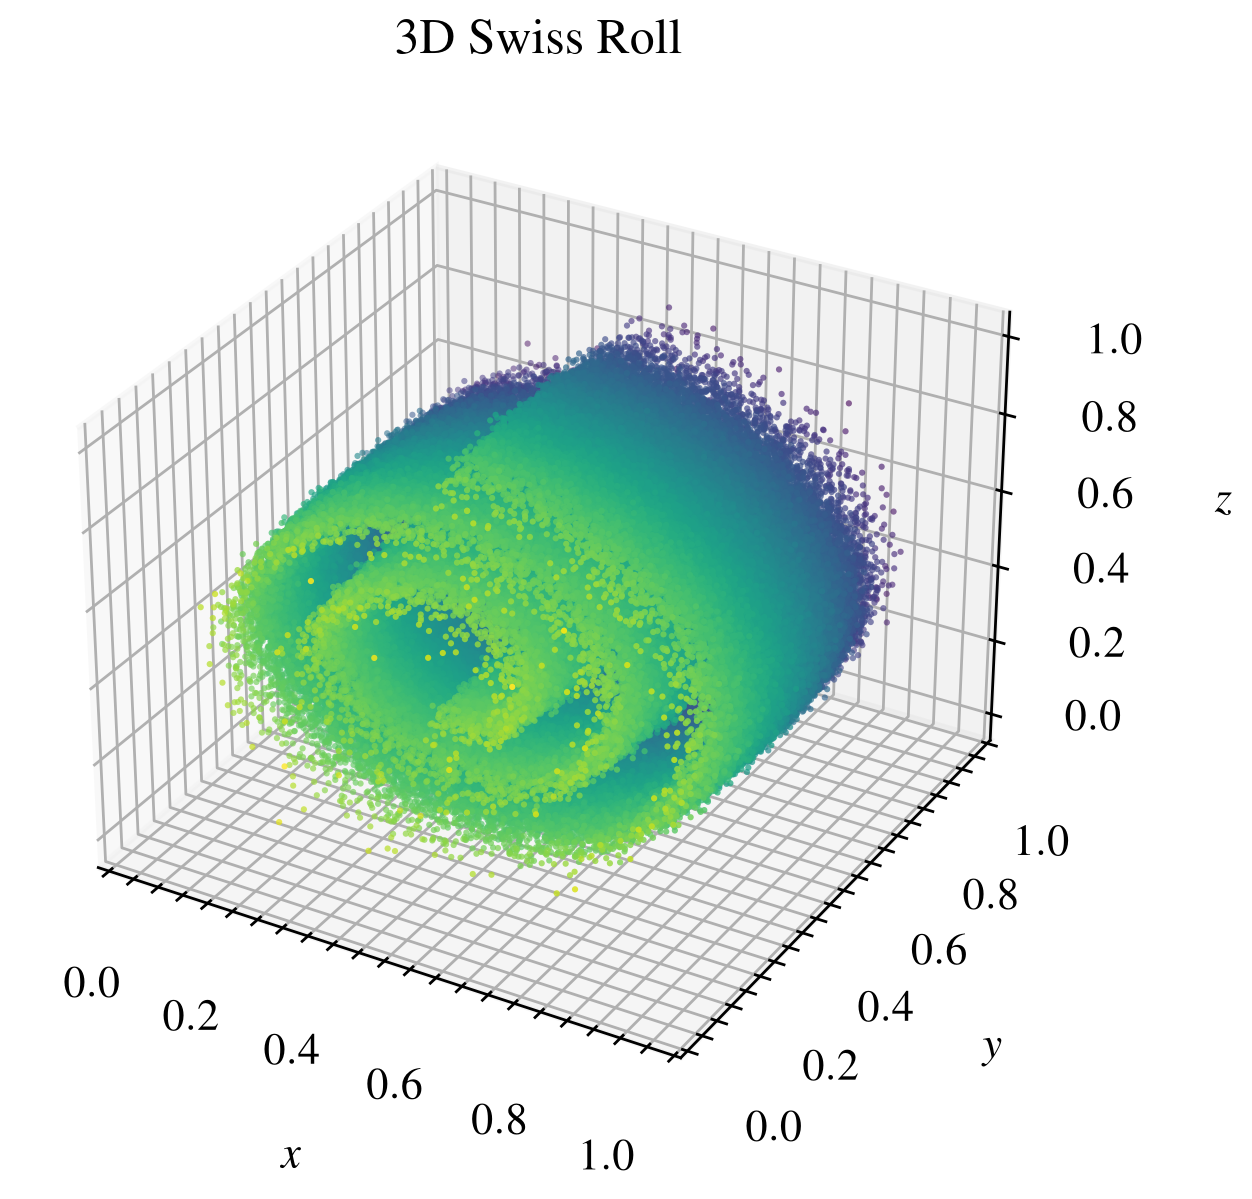

In [4]:
fig = plt.figure(figsize=(4, 3))
ax = fig.add_subplot(projection='3d')

ax.scatter(positions[:, 0],
           positions[:, 1],
           positions[:, 2],
           marker='.',
           s=5,
           edgecolors='none',
           c=-positions[:, 1],
           cmap='viridis',
           )

ax.set_title('3D Swiss Roll', fontsize=9)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$z$')

plt.tight_layout()
plt.show()

Next, we initialize a point cloud instance in an open box with weights set to ones, a quintic spline kernel and 32 nearest neighbors to use during operations:

In [5]:
pc = sm.PointCloud(positions=positions, weights=weights)\
    .global_setup(kernel_name='quintic_spline', num_neighbors=32)

[Taichi] Starting on arch=metal
[smudgy] Set taichi backend
[smudgy] Using 1 MPI rank
[smudgy] Initialized 3d PointCloud with 500000 particles without periodicity
[smudgy] Set kernel to 'quintic_spline'
[smudgy] Set number of neighbors to 32


Next, we compute all the relevant smoothing quantities both for `isotropic` and `covariant` structures:

In [6]:
pc.compute_smoothing(structure='isotropic')
pc.compute_smoothing(structure='covariant')

[smudgy] Building kd-tree from positions
[smudgy] Computing smoothing lengths from 32 neighbors
[smudgy] Computing smoothing tensors from 32 neighbors


### Projecting smoothing tensors

While projecting isotropic kernels is trivial, projecting a 3D smoothing tensor $H \in \mathbb{R}^{3\times 3}$ into a 2D plane proceeds by working with its inverse (a metric form) and restricting it to a chosen subspace spanned by two vectors $p_1$ and $p_2$. These basis vectors form the rows of the projection matrix $P \in \mathbb{R}^{2\times 3}$. The projected smoothing tensor is then computed via a simple matrix multiplication:

$$H_{2D} = \left(P\, H^{-1}\, P^\top\right)^{-1}
\qquad \text{where} \qquad
P =
\begin{bmatrix}
p_1^\top \\ 
p_2^\top
\end{bmatrix}
\in \mathbb{R}^{2\times 3}.
$$

The 2D eigenvalues and -vectors are then readily computed from the projected smoothing tensor.

Below we show a visual example of projecting smoothing ellipsoides defined by $H$ onto the $x-y$ plane, using the utiliy function `project_2d`. This function is readily available for both backends and can be imported from `smudgy.backend.numpy.tensor_utils`, or `smudgy.backend.taichi.tensor_utils` for the taichi version.

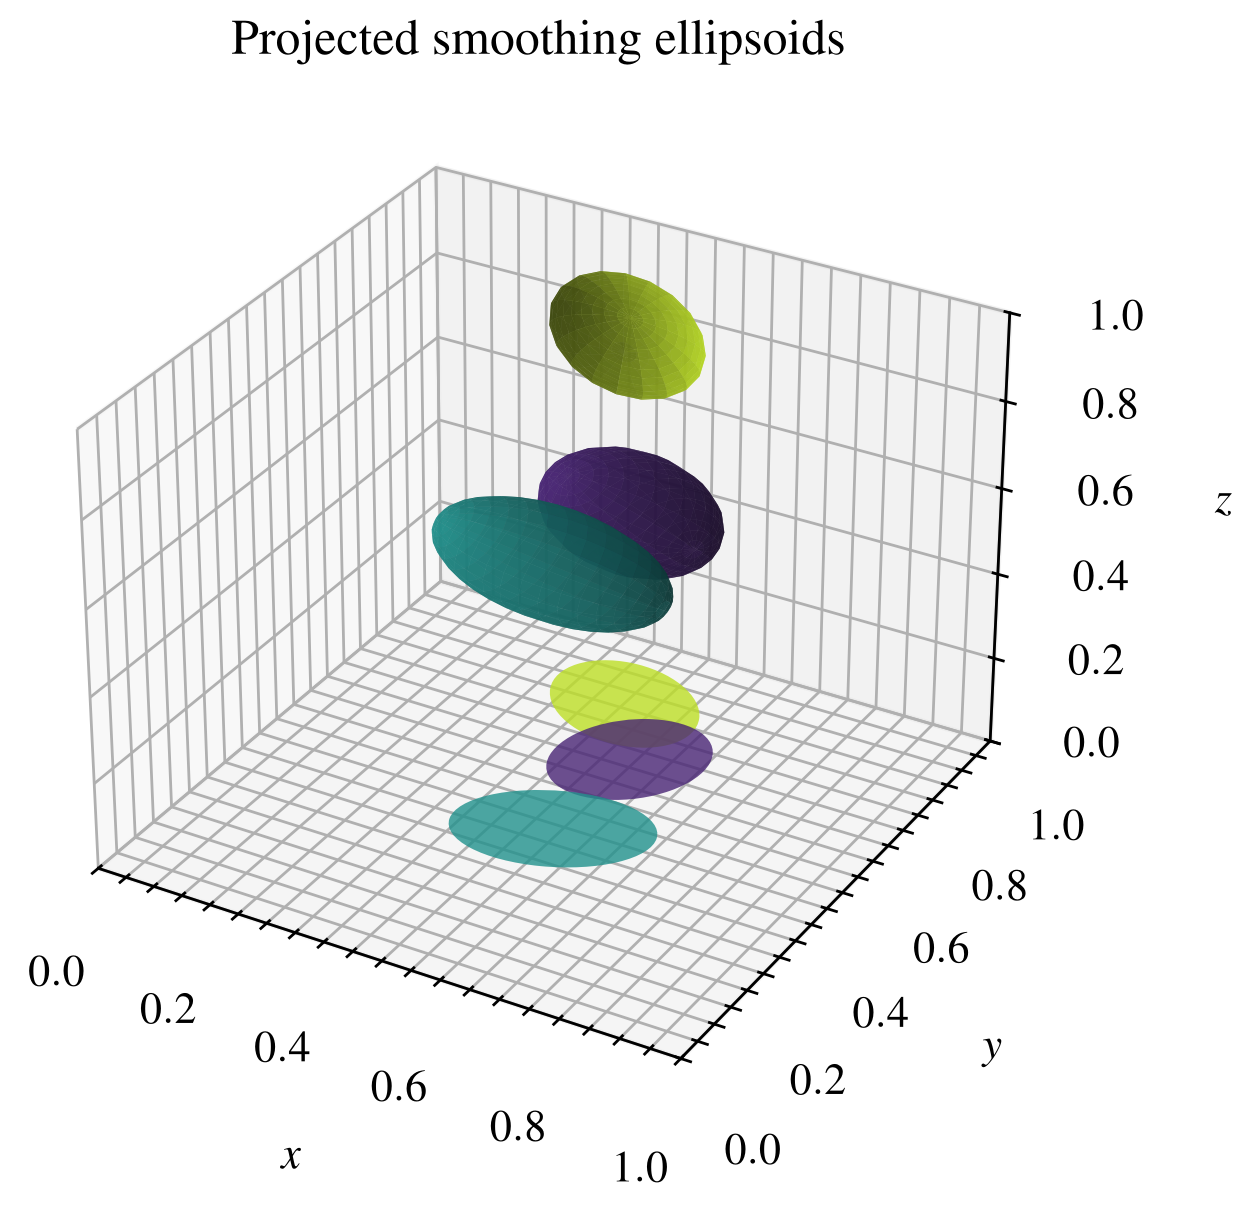

In [7]:
from helpers import plot_projection_demo

fig, ax3d = plot_projection_demo(N=3)
plt.tight_layout()
plt.show()

### Projected depositions in `smudgy`

Now we will deposit the particle weight field to a 2D grid by projecting the smoothing lengths and tensors onto the relevant projection planes.
Currently, only projection planes spanned by two of the three cartesian axes are possible. Users can simply pass a list or tuple of axis indices as the `plane_projection` argument. E.g. `plane_projection=[0, 1]` will project onto the $x-y$ plane, while `plane_projection=[2, 1]` will project onto the $z-y$ plane.

In [8]:
buffer = 0.2
kwargs = dict(
    fields=['weights'],
    averaged=False,
    gridnums=200,
    extent=[[-buffer, height+buffer], [-buffer, height+buffer], [-buffer, height+buffer]],
)

grid_2d_iso = pc.deposit(
    **kwargs,
    structure='isotropic',
    plane_projection=[0, 2],
)

grid_2d_cov = pc.deposit(
    **kwargs,
    structure='covariant',
    plane_projection=[0, 2],
)

[smudgy] Depositing using isotropic 'quintic_spline' kernel


TypeError: project_2d() got an unexpected keyword argument 'basis'

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2), sharex=True, sharey=True)

kwargs = dict(
    extent = [-buffer, height+buffer, -buffer, height+buffer],
    cmap = 'Blues'
)

ax[0].imshow(np.rot90(grid_2d_iso),
             **kwargs
             )

ax[1].imshow(np.rot90(grid_2d_cov),
             **kwargs
             )
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$z$')
ax[1].set_xlabel(r'$x$')

ax[0].set_title('Isotropic Smoothing')
ax[1].set_title('Covariant Smoothing')

fig.savefig("projection_comparison.png", dpi=500, bbox_inches="tight")

```{image} projection_comparison.png
:width: 100%
:align: center